clusting city , category_name  and partioning by date from 2022 to 2026 . and copy dataset

In [ ]:
# 1. Mount Google Drive (This allows us to save the file permanently)
from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os
from google.colab import drive

# 1. Drive Connect
drive.mount('/content/drive')

# 2. Aapke Data Folder mein Jaana
os.chdir('/content/drive/MyDrive/A1_IOWA')

# 3. Check karna ki sab sahi hai
print("Current Folder:", os.getcwd())
print("Files Here:", os.listdir('.'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Current Folder: /content/drive/MyDrive/A1_IOWA
Files Here: ['iowa_liquor_2022_2026.parquet', '.ipynb_checkpoints', 'iowa_liquor_2022_2026_copy.parquet', 'iowa__2025_2026_copy.parquet', 'sales_history.parquet', 'vendor_list.csv', 'sales_history_V1.parquet']


In [ ]:
# 2. Authenticate and Initialize BigQuery
from google.colab import auth
from google.cloud import bigquery
import pandas as pd

auth.authenticate_user()
project_id = 'iowa-liquor-analysis-486814' # Your Project ID
client = bigquery.Client(project=project_id)

In [ ]:
# 3. The "Diet" Query (Optimized for RAM)
# We select only the essential columns to ensure the download doesn't crash Colab.
query = """
SELECT
    *
FROM `bigquery-public-data.iowa_liquor_sales.sales`
WHERE date >= '2022-01-01'
"""

print("🚀 Starting download... (This takes about 60-90 seconds)")

# This downloads the data into your Colab RAM
df = client.query(query).to_dataframe()

print(f"✅ Download Complete! Rows extracted: {len(df)}")
print(f"   Memory Usage: {df.memory_usage(deep=True).sum() / 1024**2 :.2f} MB")

# 4. Save to Parquet (The "Save Point")
# We use 'snappy' compression by default, which is fast and small.
file_path = '/content/drive/My Drive/A1_IOWA/iowa_liquor_2022_2026.parquet'

print(f"💾 Saving to Google Drive: {file_path}...")
df.to_parquet(file_path)

print("🎉 SUCCESS! Your data is safe. You can now delete the BigQuery table if needed.")

🚀 Starting download... (This takes about 60-90 seconds)
✅ Download Complete! Rows extracted: 10468712
   Memory Usage: 9726.19 MB
💾 Saving to Google Drive: /content/drive/My Drive/A1_IOWA/iowa_liquor_2022_2026.parquet...
🎉 SUCCESS! Your data is safe. You can now delete the BigQuery table if needed.


make duplicate

In [ ]:
import shutil

# Original file path
source_path = "/content/drive/MyDrive/A1_IOWA/iowa_liquor_2022_2026.parquet"

# New duplicate file path (name change kar sakte ho)
duplicate_path = "/content/drive/MyDrive/A1_IOWA/iowa_liquor_2022_2026_copy.parquet"

# Create duplicate
shutil.copy(source_path, duplicate_path)

print("Duplicate file created successfully!")


Duplicate file created successfully!


# path 1 of business question 1

In [ ]:
import duckdb
import pandas

In [ ]:
path='/content/drive/MyDrive/A1_IOWA/iowa_liquor_2022_2026_copy.parquet'

In [ ]:
q=f"""
select *
from '{path}'
limit 5
"""
r= duckdb.query(q).df()
r

,invoice_and_item_number,date,store_number,store_name,address,city,zip_code,store_location,county_number,county,...,item_number,item_description,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
0,INV-60227200032,2023-07-12,3899,WAL-MART 3762 / WDM,6365 STAGECOACH DR,WEST DES MOINES,50266,POINT(-93.797594027 41.558407006),None,POLK,...,38178,TITOS HANDMADE VODKA,6,1750,19.00,28.50,102,2907.00,178.5,47.15
1,INV-70066900087,2024-05-10,5916,ANOTHER ROUND / DEWITT,622 S 6TH AVE,DEWITT,52742,POINT(-90.538977463 41.809946437),None,CLINTON,...,89197,JOSE CUERVO ESPECIAL REPOSADO,12,1000,15.00,22.50,180,4050.00,180.0,47.55
2,INV-55179200009,2023-01-23,5555,SUB EXPRESS & GAS,4307 W LOCUST ST,DAVENPORT,52804,POINT(-90.63733 41.53816),None,SCOTT,...,64870,FIREBALL CINNAMON WHISKEY,48,100,1.00,1.50,192,259.20,19.2,5.07
3,INV-53592100010,2022-12-02,4140,FAREWAY STORES #900 / EUCLID,100 EUCLID AVE,DES MOINES,50313.0,POINT(-93.61897 41.6277),None,POLK,...,26826,JACK DANIELS OLD #7 BLACK LABEL,12,750,15.91,23.87,36,859.32,27.0,7.13
4,INV-67388800097,2024-02-16,5916,ANOTHER ROUND / DEWITT,622 S 6TH AVE,DEWITT,52742,POINT(-90.538996227 41.809630534),None,CLINTON,...,88296,PATRON SILVER,12,750,28.00,42.00,60,2520.00,45.0,11.88


In [ ]:
q=f"""
select *
from '{path}'
limit 5
"""
r= duckdb.query(q).df()
r.columns

Index(['invoice_and_item_number', 'date', 'store_number', 'store_name',
       'address', 'city', 'zip_code', 'store_location', 'county_number',
       'county', 'category', 'category_name', 'vendor_number', 'vendor_name',
       'item_number', 'item_description', 'pack', 'bottle_volume_ml',
       'state_bottle_cost', 'state_bottle_retail', 'bottles_sold',
       'sale_dollars', 'volume_sold_liters', 'volume_sold_gallons'],
      dtype='object')

In [ ]:
q=f"""
select count(*)
from '{path}'
"""
r= duckdb.query(q).df()
r

,count_star()
0,10468712


In [ ]:
q=f"""
select sum(sale_dollars)
from '{path}'
group by vendor_name
order by sum(sale_dollars)  desc
limit 5
"""
r= duckdb.query(q).df()
r

,sum(sale_dollars)
0,3.626465e+08
1,2.777629e+08
2,1.208576e+08
3,1.093457e+08
4,1.083497e+08


1 crore = 100 lackh ( indian)

10,468,712 ≈ 1.05 crore

1 million = 10 lackh ( international )

10,468,712 ≈ 10.47 million


 # buisness question ::

**The "Distribution Void" Hunter**:

**Question**: "Which high-performing stores in Iowa are currently selling huge amounts of my direct competitor's product, but have sold ZERO bottles of my product in the last 6 months?"


Iowa ke kaunse high-performing stores mere competitor ka product bahut zyada quantity mein bech rahe hain, lekin pichhle 6 mahine mein mere product ki ek bhi bottle nahi bechi?”

we are solving only for 1 year 2025 to 2026

In [ ]:
import duckdb

# File paths
input_file = "/content/drive/MyDrive/A1_IOWA/iowa_liquor_2022_2026_copy.parquet"
output_file = "/content/drive/MyDrive/A1_IOWA/iowa__2025_2026_copy.parquet"

# Create new parquet file with filtered data
duckdb.sql(f"""
COPY (
    SELECT *
    FROM read_parquet('{input_file}')
    WHERE date >= DATE '2025-01-01'
      AND date <= DATE '2026-01-30'
)
TO '{output_file}'
(FORMAT PARQUET);
""")

print("✅ New Parquet File Created Successfully!")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

✅ New Parquet File Created Successfully!


datasetof 2025 anmd 2026

In [ ]:
output_file = "/content/drive/MyDrive/A1_IOWA/iowa__2025_2026_copy.parquet"

In [ ]:
import duckdb
q=f"""
select max(date) , min(date)
from '{output_file}'

"""
r= duckdb.query(q).df()
r

,max(date),min(date)
0,2026-01-30,2025-01-01


In [ ]:
import duckdb
q=f"""
select date , store_name , city , store_location , county ,
 vendor_name ,  item_description , sale_dollars , bottles_sold ,
 state_bottle_retail
from '{output_file}'
limit 5

"""
df= duckdb.query(q).df()
df

,date,store_name,city,store_location,county,vendor_name,item_description,sale_dollars,bottles_sold,state_bottle_retail
0,2025-10-09,HAPPY'S WINE & SPIRITS WHOLESALE,CEDAR FALLS,POINT(-92.42849 42.51302),BLACK HAWK,SAZERAC COMPANY INC,FIREBALL CINNAMON WHISKEY,648.0,36,18.00
1,2025-11-25,HAPPY'S WINE & SPIRITS WHOLESALE,CEDAR FALLS,POINT(-92.42849 42.51302),BLACK HAWK,DIAGEO AMERICAS,RUMPLE MINZE PEPPERMINT SCHNAPPS LIQUEUR,6117.6,240,25.49
2,2025-10-08,CASEY'S GENERAL STORE #3333 / PLEASANT HILL,PLEASANT HILL,POINT(-93.50438 41.60007),POLK,SAZERAC COMPANY INC,FIREBALL CINNAMON WHISKEY,216.0,144,1.50
3,2025-07-24,WAL-MART 0749 / AMES,AMES,POINT(-93.62263 42.05371),STORY,"FIFTH GENERATION DISTILLED SPIRITS, INC.",TITOS HANDMADE VODKA,855.0,30,28.50
4,2025-09-18,WAL-MART 0810 / MASON CITY,MASON CITY,POINT(-93.26371 43.14821),CERRO GORDO,DIAGEO AMERICAS,KETEL ONE W/ COCKTAIL SHAKER,306.0,18,17.00


STORY CITY LIQUOR & GROCERIES / STORY CITY

In [ ]:
import duckdb
q=f"""

select *
from '{output_file}'
where store_name = 'STORY CITY LIQUOR & GROCERIES / STORY CITY'

"""
r =duckdb.query(q).df()
r

,invoice_and_item_number,date,store_number,store_name,address,city,zip_code,store_location,county_number,county,...,item_number,item_description,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
0,INV-85647500023,2025-08-19,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,64870,FIREBALL CINNAMON WHISKEY,48,100,1.00,1.50,192,288.00,19.2,5.07
1,INV-87131500002,2025-09-30,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,11299,CROWN ROYAL,44,200,5.00,7.50,44,330.00,8.8,2.32
2,INV-82492000018,2025-05-13,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,65013,FIREBALL CINNAMON WHISKEY MINI SLEEVE,12,50,4.37,6.56,48,314.88,2.4,0.63
3,INV-79719800009,2025-02-18,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248,POINT(-93.59483 42.1871),None,STORY,...,26414,ARROGANT BASTARD WHISKEY,6,700,24.00,36.00,2,72.00,1.4,0.36
4,INV-90682300016,2026-01-13,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,65344,JINRO STRAWBERRY SOJU,20,375,2.91,4.37,20,87.40,7.5,1.98
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1517,INV-82492000009,2025-05-13,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248,POINT(-93.59483 42.1871),None,STORY,...,36308,HAWKEYE VODKA,6,1750,7.50,11.25,12,135.00,21.0,5.54
1518,INV-80933400017,2025-03-25,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,36875,BLUE OX VODKA,6,1750,7.63,11.45,12,137.40,21.0,5.54
1519,INV-85647500022,2025-08-19,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,57120,CHI-CHI'S LONG ISLAND ICED TEA,6,1750,6.50,9.75,12,117.00,21.0,5.54
1520,INV-81382400013,2025-04-08,10540,STORY CITY LIQUOR & GROCERIES / STORY CITY,622 BROAD STREET,STORY CITY,50248.0,POINT(-93.59483 42.1871),None,STORY,...,36308,HAWKEYE VODKA,6,1750,7.50,11.25,12,135.00,21.0,5.54


In [ ]:
import duckdb
q=f"""
create or replace view cleaning_iowa as
select date , store_name , city , store_location , county ,
 vendor_name ,  item_description , sale_dollars , bottles_sold ,
 state_bottle_retail
from '{output_file}'

"""
duckdb.query(q)

date

In [ ]:
# SQL Equivalent to: print("Column Type:", df['date'].dtype)
duckdb.query("DESCRIBE cleaning_iowa").show()

┌─────────────────────┬─────────────┬─────────┬─────────┬─────────┬─────────┐
│     column_name     │ column_type │  null   │   key   │ default │  extra  │
│       varchar       │   varchar   │ varchar │ varchar │ varchar │ varchar │
├─────────────────────┼─────────────┼─────────┼─────────┼─────────┼─────────┤
│ date                │ DATE        │ YES     │ NULL    │ NULL    │ NULL    │
│ store_name          │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ city                │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ store_location      │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ county              │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ vendor_name         │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ item_description    │ VARCHAR     │ YES     │ NULL    │ NULL    │ NULL    │
│ sale_dollars        │ DOUBLE      │ YES     │ NULL    │ NULL    │ NULL    │
│ bottles_sold        │ BIGINT      │ YES     │ NULL    │ NULL  

In [ ]:
# Check for Gaps (Monthly Timeline)
q_gaps = """
SELECT
    DATE_TRUNC('month', date) AS month_start,
    COUNT(*) AS total_sales
FROM cleaning_iowa
GROUP BY 1
ORDER BY 1 ASC;
"""
duckdb.query(q_gaps).show()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────────┬─────────────┐
│ month_start │ total_sales │
│    date     │    int64    │
├─────────────┼─────────────┤
│ 2025-01-01  │      200509 │
│ 2025-02-01  │      176352 │
│ 2025-03-01  │      195133 │
│ 2025-04-01  │      211280 │
│ 2025-05-01  │      211097 │
│ 2025-06-01  │      219158 │
│ 2025-07-01  │      210029 │
│ 2025-08-01  │      204260 │
│ 2025-09-01  │      206162 │
│ 2025-10-01  │      214816 │
│ 2025-11-01  │      195311 │
│ 2025-12-01  │      246513 │
│ 2026-01-01  │      182995 │
├─────────────┴─────────────┤
│ 13 rows         2 columns │
└───────────────────────────┘



In [ ]:
# Check for "Fake" Dates (Day of Month)
q_fake_dates = """
SELECT
    EXTRACT(day FROM date) AS day_number,
    COUNT(*) AS frequency
FROM cleaning_iowa
GROUP BY 1
ORDER BY 2 DESC

"""
duckdb.query(q_fake_dates).show()

┌────────────┬───────────┐
│ day_number │ frequency │
│   int64    │   int64   │
├────────────┼───────────┤
│         21 │    100365 │
│         28 │    100254 │
│         24 │     97533 │
│         19 │     95644 │
│          2 │     94101 │
│         10 │     93793 │
│         29 │     93588 │
│         14 │     93512 │
│         23 │     93102 │
│          3 │     92885 │
│          · │       ·   │
│          · │       ·   │
│          · │       ·   │
│         20 │     84053 │
│         15 │     83714 │
│         30 │     82384 │
│         27 │     81611 │
│         26 │     80168 │
│         25 │     79587 │
│         13 │     79531 │
│          4 │     77430 │
│          1 │     59665 │
│         31 │     44238 │
├────────────┴───────────┤
│   31 rows (20 shown)   │
└────────────────────────┘



string  _> city

# dirty -> city column : null , space , ghost space

space

In [ ]:
import duckdb

# 1. THE "HEAD" CHECK (First 20 Cities A->Z)
# Look for: Lowercase names (ames), symbols, or numbers at the start
print("--- FIRST 20 CITIES (A-Z) ---")
q_head = """
SELECT DISTINCT city
FROM cleaning_iowa
ORDER BY city ASC
LIMIT 20;
"""
duckdb.sql(q_head).show()

# 2. THE "TAIL" CHECK (Last 20 Cities Z->A)
# Look for: "Zwingle", lowercase z's, or empty strings/NULLs
print("\n--- LAST 20 CITIES (Z-A) ---")
q_tail = """
SELECT DISTINCT city
FROM cleaning_iowa
ORDER BY city DESC
LIMIT 20;
"""
duckdb.sql(q_tail).show()

--- FIRST 20 CITIES (A-Z) ---
┌─────────────┐
│    city     │
│   varchar   │
├─────────────┤
│ ACKLEY      │
│ ADAIR       │
│ ADEL        │
│ AFTON       │
│ AINSWORTH   │
│ AKRON       │
│ ALBERT CITY │
│ ALBIA       │
│ ALBION      │
│ ALBURNETT   │
│ ALDEN       │
│ ALGONA      │
│ ALLERTON    │
│ ALLISON     │
│ ALTA        │
│ ALTON       │
│ ALTOONA     │
│ AMANA       │
│ AMES        │
│ ANAMOSA     │
├─────────────┤
│   20 rows   │
└─────────────┘


--- LAST 20 CITIES (Z-A) ---
┌─────────────────┐
│      city       │
│     varchar     │
├─────────────────┤
│ ZWINGLE         │
│ WYOMING         │
│ WOODWARD        │
│ WOODBINE        │
│ WINTHROP        │
│ WINTERSET       │
│ WINFIELD        │
│ WINDSOR HEIGHTS │
│ WILTON          │
│ WILLIAMSBURG    │
│ WHITTEMORE      │
│ WHITING         │
│ WHEATLAND       │
│ WHAT CHEER      │
│ WEVER           │
│ WEST UNION      │
│ WEST POINT      │
│ WEST LIBERTY    │
│ WEST DES MOINES │
│ WEST BURLINGTON │
├─────────────────┤
│     2

null

In [ ]:

q_null = """
SELECT DISTINCT city , count(*)
FROM cleaning_iowa
where city is null
group  by city


"""

duckdb.sql(q_null).show()

┌─────────┬──────────────┐
│  city   │ count_star() │
│ varchar │    int64     │
├─────────┼──────────────┤
│ NULL    │         1668 │
└─────────┴──────────────┘



In [ ]:

q_null = """
SELECT
    city,
    UPPER(city) as clean_version,
    COUNT(*) as problematic_rows
FROM cleaning_iowa
WHERE city != UPPER(city)  -- This finds the lowercase ones
GROUP BY 1, 2
ORDER BY 3 DESC;


"""

duckdb.sql(q_null).show()

┌─────────┬───────────────┬──────────────────┐
│  city   │ clean_version │ problematic_rows │
│ varchar │    varchar    │      int64       │
├─────────┴───────────────┴──────────────────┤
│                   0 rows                   │
└────────────────────────────────────────────┘



same4 problme in string based column : county , city , vendor name , item description , store name

vendor name :

**The "Double Space" Bug (High Risk)**

**Problem:** Row 188: SAZERAC COMPANY  INC has two spaces between "COMPANY" and "INC".

**Why it's bad:** If you have another row with a single space, Power BI will treat them as two different companies, splitting your sales data for Sazerac.

-----------------------------------------------------------------------------

**Punctuation Inconsistency (The "Dot" Problem)**
You have a mix of abbreviated styles which makes the list look "jittery" in a slicer:

**INC vs INC.:** 16 vendors use a period (e.g., BLUE OX SPIRITS, INC.), while 32 others do not.

**CORP vs CORP.:** You have BANFI PRODUCTS CORP. (with dot) vs others without.

**CO vs CO.:** 4 vendors use CO. (e.g., MCCORMICK DISTILLING CO.) while others use CO.

------------------------------------------------------------------------------

**Naming Fragmentation (CO vs COMPANY)**
Found: 10 vendors use the abbreviation CO, while 23 use the full word COMPANY.

**The Risk:** In the liquor industry, it is very common for a vendor to be entered as "X Distilling Co" one day and "X Distilling Company" the next. Even if they aren't duplicates in this specific list, it proves your source data is inconsistent.

-------------------------------------------------------------------------------

**Commas vs No Commas**
Example: Some use , LLC and others just  LLC. This creates a visual "zigzag" when users scroll through your vendor filter.


done : county , city , vendor name


store name

**The "Double Space" Problem (33 Rows)**

What I found: 33 store names have accidental double spaces inside them.

**Examples:**

BEST FOOD MART 3  LLC (Two spaces before LLC)

BP TO GO  #3 / CEDAR RAPIDS

**Why it matters:** Power BI is strict. If you have "Best Food Mart" (1 space) in one month and "Best Food Mart  " (2 spaces) in another, it treats them as two completely different stores, splitting your sales history.

**The "Punctuation" Inconsistency (28 Rows)**
What I found: You have a mix of styles for abbreviations.

**Examples:**

Some use dots: BOYD GROCERY, INC.

Most others do not: BOYD GROCERY INC

**Why it matters:**  It creates "jitter" in your slicers. Seeing INC. and INC next to each other looks messy to an executive.

item description

**The "Double Space" Glitch (16 Rows)**

What I found: 16 product descriptions have accidental double spaces.

Examples:

CENTURY FARMS AMERICAN CLASSIC -  PERSONALIZED (Two spaces after the dash).

DRAGON FANDANGO VODKA  BERRY (Two spaces before Berry).

**Why it matters:** Just like with vendors, if "Dragon Fandango" is spelled with one space in January and two spaces in February, Power BI will split them into two different products. It ruins your "Top Selling Products" chart.

# second question Neighborhood War

In [ ]:
path='/content/drive/MyDrive/A1_IOWA/iowa_liquor_2022_2026_copy.parquet'
import duckdb

In [ ]:
q=f"""
with date_col as (
  select EXTRACT(YEAR FROM date)  AS year,
    EXTRACT(MONTH FROM date) AS month,
    EXTRACT(DAY FROM date)   AS day
  from '{path}'
)
select  max(year) , max(month) , max(day)
from date_col
where year = 2025
"""
r= duckdb.query(q).df()
r

,"max(""year"")","max(""month"")","max(""day"")"
0,2025,12,31


In [ ]:
q=f"""
create or replace view sales_history as
select *
from '{path}'
where date between  date '2022-01-01' and date '2025-12-31'

"""
duckdb.query(q)
print('completed')


completed


In [ ]:
q=f"""
select min(date) ,  max(date)
from sales_history
"""
r= duckdb.query(q).df()
r

,min(date),max(date)
0,2022-01-02,2025-12-31


In [ ]:
# path configure
path = '/content/drive/MyDrive/A1_IOWA/sales_history.parquet'

# save
duckdb.sql(f"""
COPY sales_history TO '{path}' (FORMAT PARQUET)

""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## orginal dataset

In [ ]:
path = '/content/drive/MyDrive/A1_IOWA/sales_history.parquet'
import duckdb

In [ ]:
q = f"""
select *
from '{path}'
limit 5

"""
r= duckdb.query(q).df()
r

,invoice_and_item_number,date,store_number,store_name,address,city,zip_code,store_location,county_number,county,...,item_number,item_description,pack,bottle_volume_ml,state_bottle_cost,state_bottle_retail,bottles_sold,sale_dollars,volume_sold_liters,volume_sold_gallons
0,INV-60227200032,2023-07-12,3899,WAL-MART 3762 / WDM,6365 STAGECOACH DR,WEST DES MOINES,50266,POINT(-93.797594027 41.558407006),None,POLK,...,38178,TITOS HANDMADE VODKA,6,1750,19.00,28.50,102,2907.00,178.5,47.15
1,INV-70066900087,2024-05-10,5916,ANOTHER ROUND / DEWITT,622 S 6TH AVE,DEWITT,52742,POINT(-90.538977463 41.809946437),None,CLINTON,...,89197,JOSE CUERVO ESPECIAL REPOSADO,12,1000,15.00,22.50,180,4050.00,180.0,47.55
2,INV-55179200009,2023-01-23,5555,SUB EXPRESS & GAS,4307 W LOCUST ST,DAVENPORT,52804,POINT(-90.63733 41.53816),None,SCOTT,...,64870,FIREBALL CINNAMON WHISKEY,48,100,1.00,1.50,192,259.20,19.2,5.07
3,INV-53592100010,2022-12-02,4140,FAREWAY STORES #900 / EUCLID,100 EUCLID AVE,DES MOINES,50313.0,POINT(-93.61897 41.6277),None,POLK,...,26826,JACK DANIELS OLD #7 BLACK LABEL,12,750,15.91,23.87,36,859.32,27.0,7.13
4,INV-67388800097,2024-02-16,5916,ANOTHER ROUND / DEWITT,622 S 6TH AVE,DEWITT,52742,POINT(-90.538996227 41.809630534),None,CLINTON,...,88296,PATRON SILVER,12,750,28.00,42.00,60,2520.00,45.0,11.88


In [ ]:
q = f"""
select count(*)
from '{path}'


"""
r= duckdb.query(q).df()
r

,count_star()
0,10285717


note : r = duckdb.query(q).df()

our system crashed because this line loads the entire Parquet file into memory
If your Iowa dataset is large (millions of rows), .df() tries to convert everything into a Pandas DataFrame → RAM overload → crash.

In [ ]:
duckdb.query(f"""
DESCRIBE SELECT * FROM '{path}'
""").df()


,column_name,column_type,null,key,default,extra
0,invoice_and_item_number,VARCHAR,YES,None,None,None
1,date,DATE,YES,None,None,None
2,store_number,VARCHAR,YES,None,None,None
3,store_name,VARCHAR,YES,None,None,None
4,address,VARCHAR,YES,None,None,None
5,city,VARCHAR,YES,None,None,None
6,zip_code,VARCHAR,YES,None,None,None
7,store_location,VARCHAR,YES,None,None,None
8,county_number,VARCHAR,YES,None,None,None
9,county,VARCHAR,YES,None,None,None


remove unnecesary column


## view 1 sales_history_v1

In [ ]:
q=f"""
create or replace view sales_history_v1 as
select date , store_name , address , city ,
store_location , county , vendor_name , item_description , sale_dollars ,
bottles_sold , state_bottle_retail , state_bottle_cost , volume_sold_liters,
bottle_volume_ml
from '{path}'


"""
duckdb.query(q)
print('completed')


completed


In [ ]:
q = f"""
select *
from sales_history_v1
limit 5

"""
r= duckdb.query(q).df()
r

,date,store_name,address,city,store_location,county,vendor_name,item_description,sale_dollars,bottles_sold,state_bottle_retail,state_bottle_cost,volume_sold_liters,bottle_volume_ml
0,2023-07-12,WAL-MART 3762 / WDM,6365 STAGECOACH DR,WEST DES MOINES,POINT(-93.797594027 41.558407006),POLK,FIFTH GENERATION INC,TITOS HANDMADE VODKA,2907.00,102,28.50,19.00,178.5,1750
1,2024-05-10,ANOTHER ROUND / DEWITT,622 S 6TH AVE,DEWITT,POINT(-90.538977463 41.809946437),CLINTON,PROXIMO,JOSE CUERVO ESPECIAL REPOSADO,4050.00,180,22.50,15.00,180.0,1000
2,2023-01-23,SUB EXPRESS & GAS,4307 W LOCUST ST,DAVENPORT,POINT(-90.63733 41.53816),SCOTT,SAZERAC COMPANY INC,FIREBALL CINNAMON WHISKEY,259.20,192,1.50,1.00,19.2,100
3,2022-12-02,FAREWAY STORES #900 / EUCLID,100 EUCLID AVE,DES MOINES,POINT(-93.61897 41.6277),POLK,BROWN FORMAN CORP.,JACK DANIELS OLD #7 BLACK LABEL,859.32,36,23.87,15.91,27.0,750
4,2024-02-16,ANOTHER ROUND / DEWITT,622 S 6TH AVE,DEWITT,POINT(-90.538996227 41.809630534),CLINTON,BACARDI USA INC,PATRON SILVER,2520.00,60,42.00,28.00,45.0,750


date- all done ✅

NO NULL VALUES

In [ ]:
q = f"""
select date
from sales_history_v1
where date is NULL

"""
r= duckdb.query(q).df()
r

,date


In [ ]:
# Check for Gaps (Monthly Timeline)
q_gaps = """
SELECT
    count(*)
FROM  sales_history_v1

"""
duckdb.query(q_gaps).show()

┌──────────────┐
│ count_star() │
│    int64     │
├──────────────┤
│     10285717 │
└──────────────┘



In [ ]:
# Check for Gaps (Monthly Timeline)
q_gaps = """
SELECT
    DATE_TRUNC('year', date) AS year_start,
    COUNT(*) AS total_sales
FROM  sales_history_v1
GROUP BY year_start
ORDER BY year_start ASC;
"""
duckdb.query(q_gaps).show()

┌─────────────┬─────────────┐
│ month_start │ total_sales │
│    date     │    int64    │
├─────────────┼─────────────┤
│ 2022-01-01  │     2564565 │
│ 2023-01-01  │     2639557 │
│ 2024-01-01  │     2590975 │
│ 2025-01-01  │     2490620 │
└─────────────┴─────────────┘



In [ ]:
q_gaps= """
select
     date_trunc('month' , date) as month_start  ,
     count(*) as total
from sales_history_v1
where year(date)= 2022
group by month_start
order by month_start asc

"""
duckdb.query(q_gaps).show()

┌─────────────┬────────┐
│ month_start │ total  │
│    date     │ int64  │
├─────────────┼────────┤
│ 2022-01-01  │ 182595 │
│ 2022-02-01  │ 174284 │
│ 2022-03-01  │ 185496 │
│ 2022-04-01  │ 211131 │
│ 2022-05-01  │ 217820 │
│ 2022-06-01  │ 236620 │
│ 2022-07-01  │ 209534 │
│ 2022-08-01  │ 237392 │
│ 2022-09-01  │ 220359 │
│ 2022-10-01  │ 213014 │
│ 2022-11-01  │ 227138 │
│ 2022-12-01  │ 249182 │
├─────────────┴────────┤
│ 12 rows    2 columns │
└──────────────────────┘



In [ ]:
# Check for "Fake" Dates (Day of Month)
q_fake_dates = """
SELECT
    EXTRACT(day FROM date) AS day_number,
    COUNT(*) AS frequency
FROM sales_history_v1
where year(date)= 2025
group by day_number

"""
duckdb.query(q_fake_dates).show()

┌────────────┬───────────┐
│ day_number │ frequency │
│   int64    │   int64   │
├────────────┼───────────┤
│          1 │     59663 │
│          2 │     82042 │
│          3 │     92885 │
│          4 │     76165 │
│          5 │     77392 │
│          6 │     81219 │
│          7 │     83369 │
│          8 │     79124 │
│          9 │     79129 │
│         10 │     93793 │
│          · │       ·   │
│          · │       ·   │
│          · │       ·   │
│         22 │     80482 │
│         23 │     83527 │
│         24 │     97533 │
│         25 │     79525 │
│         26 │     71167 │
│         27 │     72545 │
│         28 │     92120 │
│         29 │     87447 │
│         30 │     73999 │
│         31 │     44238 │
├────────────┴───────────┤
│   31 rows (20 shown)   │
└────────────────────────┘



city , county

In [ ]:
q = f"""
select  city
from sales_history_v1
where county is null
limit 5

"""
r= duckdb.query(q).df()
r

,city
0,None
1,None
2,None
3,None
4,None


## view 2 sales_history_v2

In [ ]:
q=f"""
create or replace view sales_history_v2 as
SELECT *exclude( city , county) ,
    -- 1. Clean the City Column
    COALESCE(
        NULLIF(
            TRIM(
                REGEXP_REPLACE(
                    UPPER(city),
                    '\s+', -- Matches any whitespace character (spaces, tabs, newlines)
                    ' ',   -- Replaces multiple/ghost spaces with ONE standard space
                    'g'    -- Global flag: applies to the entire string
                )
            ),
        ''),
    'UNKNOWN') AS clean_city,

    -- 2. Clean the County Column
    COALESCE(
        NULLIF(
            TRIM(
                REGEXP_REPLACE(
                    UPPER(county),
                    '\s+',
                    ' ',
                    'g'
                )
            ),
        ''),
    'UNKNOWN') AS clean_county

FROM sales_history_v1



"""
duckdb.query(q)
print('completed')


completed


<>:45: SyntaxWarning: invalid escape sequence '\s'
<>:45: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2736883344.py:45: SyntaxWarning: invalid escape sequence '\s'


In [ ]:
# Check for "Fake" Dates (Day of Month)
q_fake_dates = """
SELECT
   *
FROM sales_history_v2
limit 5


"""
duckdb.query(q_fake_dates).show()

┌────────────┬──────────────────────────────┬────────────────────┬───────────────────────────────────┬──────────────────────┬─────────────────────────────────┬──────────────┬──────────────┬─────────────────────┬───────────────────┬────────────────────┬──────────────────┬─────────────────┬──────────────┐
│    date    │          store_name          │      address       │          store_location           │     vendor_name      │        item_description         │ sale_dollars │ bottles_sold │ state_bottle_retail │ state_bottle_cost │ volume_sold_liters │ bottle_volume_ml │   clean_city    │ clean_county │
│    date    │           varchar            │      varchar       │              varchar              │       varchar        │             varchar             │    double    │    int64     │       double        │      double       │       double       │      int64       │     varchar     │   varchar    │
├────────────┼──────────────────────────────┼────────────────────┼───────────────────

check

In [ ]:
# Check for "Fake" Dates (Day of Month)
q_fake_dates = """
SELECT
    clean_city  ,
    COUNT(*) as row_count
FROM sales_history_v2
WHERE clean_city  IS NULL
   OR TRIM(clean_city ) = ''
GROUP BY clean_city
ORDER BY row_count DESC;

"""
duckdb.query(q_fake_dates).show()

┌────────────┬───────────┐
│ clean_city │ row_count │
│  varchar   │   int64   │
├────────────┴───────────┤
│         0 rows         │
└────────────────────────┘



In [ ]:
# Check for "Fake" Dates (Day of Month)
q_fake_dates = """
SELECT DISTINCT
    clean_city ,
    LENGTH(clean_city) as actual_length,
    LENGTH(TRIM(clean_city)) as trimmed_length
FROM sales_history_v2
WHERE clean_city  LIKE ' %'    -- Detects Leading space
   OR clean_city  LIKE '% '    -- Detects Trailing space
   OR clean_city  LIKE '%  %'; -- Detects Double spaces inside the name

"""
duckdb.query(q_fake_dates).show()

┌────────────┬───────────────┬────────────────┐
│ clean_city │ actual_length │ trimmed_length │
│  varchar   │     int64     │     int64      │
├────────────┴───────────────┴────────────────┤
│                   0 rows                    │
└─────────────────────────────────────────────┘



In [ ]:

q_fakes = """
SELECT DISTINCT
    city
FROM sales_history_v1
WHERE REGEXP_MATCHES(city, '[\t\r\n]') -- Finds hidden tabs and newlines
   OR (REGEXP_MATCHES(city, '\s') AND NOT REGEXP_MATCHES(city, ' ')); -- Finds ANY whitespace that is not a standard spacebar stroke

"""
duckdb.query(q_fakes).show()

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-2109895419.py:6: SyntaxWarning: invalid escape sequence '\s'
  OR (REGEXP_MATCHES(city, '\s') AND NOT REGEXP_MATCHES(city, ' ')); -- Finds ANY whitespace that is not a standard spacebar stroke


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

┌─────────┐
│  city   │
│ varchar │
├─────────┤
│ 0 rows  │
└─────────┘



city , county ✅

In [ ]:

q_fake_dates = """
SELECT
    clean_county
FROM sales_history_v2
group by clean_county
order by clean_county  asc
limit 1 offset 1


"""
r=duckdb.query(q_fake_dates).df()
r

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,clean_county
0,ADAMS


In [ ]:

q_fake_dates = """
SELECT
    *
FROM sales_history_v2




"""
r=duckdb.query(q_fake_dates).df()
r.columns

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Index(['date', 'city', 'store_location', 'county', 'sale_dollars',
       'bottles_sold', 'state_bottle_retail', 'state_bottle_cost',
       'volume_sold_liters', 'bottle_volume_ml', 'clean_store_name',
       'clean_address', 'clean_vendor_name', 'clean_item_description'],
      dtype='object')

## view 3 sales_history_v3

In [ ]:
q=f"""
create or replace view sales_history_v3 as
SELECT *exclude( store_name , address , vendor_name , item_description ) ,
    -- 1. Clean the store_name Column
    COALESCE(
        NULLIF(
            TRIM(
                REGEXP_REPLACE(
                    UPPER(store_name),
                    '\s+', -- Matches any whitespace character (spaces, tabs, newlines)
                    ' ',   -- Replaces multiple/ghost spaces with ONE standard space
                    'g'    -- Global flag: applies to the entire string
                )
            ),
        ''),
    'UNKNOWN STORE') AS clean_store_name,

    -- 2. Clean the address Column
    COALESCE(
        NULLIF(
            TRIM(
                REGEXP_REPLACE(
                    UPPER(address),
                    '\s+',
                    ' ',
                    'g'
                )
            ),
        ''),
    'UNKNOWN ADDRESS') AS clean_address ,

    -- 3. Clean the Vendor Name Column
    COALESCE(
        NULLIF(
            TRIM(
                REGEXP_REPLACE(
                    UPPER(vendor_name),
                    '\s+',
                    ' ',
                    'g'
                )
            ),
        ''),
    'UNKNOWN VENDOR') AS clean_vendor_name ,

    -- 4. Clean the Item Description Column
    COALESCE(
        NULLIF(
            TRIM(
                REGEXP_REPLACE(
                    UPPER(item_description),
                    '\s+',
                    ' ',
                    'g'
                )
            ),
        ''),
    'UNKNOWN ITEM') AS clean_item_description

FROM sales_history_v2



"""
duckdb.query(q)
print('completed')


completed


<>:73: SyntaxWarning: invalid escape sequence '\s'
<>:73: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-1576613496.py:73: SyntaxWarning: invalid escape sequence '\s'


In [ ]:

q = """
SELECT
   *
FROM sales_history_v3
limit 5


"""
duckdb.query(q).show()

┌────────────┬───────────────────────────────────┬──────────────┬──────────────┬─────────────────────┬───────────────────┬────────────────────┬──────────────────┬─────────────────┬──────────────┬──────────────────────────────┬────────────────────┬──────────────────────┬─────────────────────────────────┐
│    date    │          store_location           │ sale_dollars │ bottles_sold │ state_bottle_retail │ state_bottle_cost │ volume_sold_liters │ bottle_volume_ml │   clean_city    │ clean_county │       clean_store_name       │   clean_address    │  clean_vendor_name   │     clean_item_description      │
│    date    │              varchar              │    double    │    int64     │       double        │      double       │       double       │      int64       │     varchar     │   varchar    │           varchar            │      varchar       │       varchar        │             varchar             │
├────────────┼───────────────────────────────────┼──────────────┼──────────────┼─────

## dirty in vendor_name

What this code does:

**KIRIN BEER & SPIRITS OF AMERICA INC / FOUR ROS...**

**$\rightarrow$ KIRIN BEER & SPIRITS OF AMERICAJOHN ERNEST DISTILLERY, INC.**

 **JOHN ERNEST DISTILLERYREMY COINTREAU USA INC $\rightarrow$ REMY COINTREAU**

 The Result: Your Power BI slicer will go from looking like a messy database dump to a sleek, executive-level menu.

Vendor Name Data Noise & Reasons

**• Legal Jargon (INC, LLC, CO, LTD):** Contains unnecessary legal entity types. Reason: Variations (like a missing comma) cause Power BI to split the exact same company into multiple different entities, which instantly ruins your Market Share DAX calculations.

**• Parent/Subsidiary Slashes (/):** Entries formatting dual names like "COMPANY / BRAND". Reason: This forces sales reps to read through two names, destroys logical alphabetical sorting in your slicer, and hides the actual brand name they are looking for.

**• Accidental Double Spaces:** Hidden extra spaces between words. Reason: The DAX engine strictly reads "BRAND INC" and "BRAND  INC" as two entirely separate companies, secretly fracturing your revenue tracking.

**• Literal Quotes:** Extraneous quotation marks wrapping the vendor names. Reason: Causes string-matching failures when joining your dimension and fact tables, resulting in blank rows in your dashboard.


In [ ]:

q_fake_dates = """
SELECT
   clean_vendor_name
FROM sales_history_v3
group by clean_vendor_name
"""
r=duckdb.query(q_fake_dates).df()
r.to_csv('vendor_list.csv' , index=False)

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## view 4 sales_history_v4

In [ ]:
q=f"""
create or replace view sales_history_v4 as
SELECT
   * EXCLUDE(clean_vendor_name),

   -- 3. Clean the Vendor Name Column (The Slicer-Ready Upgrade)
    COALESCE(
        NULLIF(
            -- RTRIM specifically hunts and kills trailing dots, commas, and spaces
            RTRIM(
                REGEXP_REPLACE(
                    REGEXP_REPLACE(
                        -- Step A: Upper case and chop off everything after the "/"
                        SPLIT_PART(UPPER(clean_vendor_name), '/', 1),

                        -- Step B: Aggressively strip INC, LLC, CO, CORP, and trailing commas
                        ',?\s*(INC\.?|LLC\.?|USA|CORP\.?|LTD\.?|COMPANY|CO\.?)\b\.?',
                        '',
                        'g'
                    ),
                    -- Step C: Crush any double spaces created by the deletion down to a single space
                    '\s+',
                    ' ',
                    'g'
                ),
                ' .,' -- The hit list of characters to strip from the very end of the string
            ),
        ''),
    'UNKNOWN VENDOR') AS extra_clean_vendor_name

FROM sales_history_v3;
"""
duckdb.query(q)
print('completed')

completed


<>:48: SyntaxWarning: invalid escape sequence '\s'
<>:48: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-328561173.py:48: SyntaxWarning: invalid escape sequence '\s'


In [ ]:

q = """
SELECT
   *
FROM sales_history_v4
limit 5


"""
r=duckdb.query(q).df()
r

,date,store_location,sale_dollars,bottles_sold,state_bottle_retail,state_bottle_cost,volume_sold_liters,bottle_volume_ml,clean_city,clean_county,clean_store_name,clean_address,clean_item_description,extra_clean_vendor_name
0,2023-07-12,POINT(-93.797594027 41.558407006),2907.00,102,28.50,19.00,178.5,1750,WEST DES MOINES,POLK,WAL-MART 3762 / WDM,6365 STAGECOACH DR,TITOS HANDMADE VODKA,FIFTH GENERATION INC
1,2024-05-10,POINT(-90.538977463 41.809946437),4050.00,180,22.50,15.00,180.0,1000,DEWITT,CLINTON,ANOTHER ROUND / DEWITT,622 S 6TH AVE,JOSE CUERVO ESPECIAL REPOSADO,PROXIMO
2,2023-01-23,POINT(-90.63733 41.53816),259.20,192,1.50,1.00,19.2,100,DAVENPORT,SCOTT,SUB EXPRESS & GAS,4307 W LOCUST ST,FIREBALL CINNAMON WHISKEY,SAZERAC COMPANY INC
3,2022-12-02,POINT(-93.61897 41.6277),859.32,36,23.87,15.91,27.0,750,DES MOINES,POLK,FAREWAY STORES #900 / EUCLID,100 EUCLID AVE,JACK DANIELS OLD #7 BLACK LABEL,BROWN FORMAN CORP
4,2024-02-16,POINT(-90.538996227 41.809630534),2520.00,60,42.00,28.00,45.0,750,DEWITT,CLINTON,ANOTHER ROUND / DEWITT,622 S 6TH AVE,PATRON SILVER,BACARDI USA INC


In [ ]:
path_update = '/content/drive/MyDrive/A1_IOWA/sales_history_V1.parquet'

duckdb.sql(f"""
COPY sales_history_v4
TO '{path_update}'
(FORMAT PARQUET);
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [ ]:
path_update = '/content/drive/MyDrive/A1_IOWA/sales_history_V1.parquet'

## view 5 sales_history_v5

clean : FIFTH GENERATION DISTILLED SPIRITS, INC

In [ ]:

q = f"""
-- 1. Create a clean table in memory directly from your Parquet file
CREATE OR REPLACE TABLE sales_history_v5 AS
SELECT
    * EXCLUDE(extra_clean_vendor_name),

    -- 2. The Armor-Piercing Vendor Name Scrubber
    COALESCE(
        NULLIF(
            -- Step D: Shave off any stray dots, commas, or dashes at the very end
            RTRIM(
                REGEXP_REPLACE(
                    REGEXP_REPLACE(
                        -- Step A: SHRED QUOTES, Upper Case, and chop at "/"
                        SPLIT_PART(UPPER(REPLACE(extra_clean_vendor_name, '"', '')), '/', 1),

                        -- Step B: Destroy commas, spaces, and the legal garbage (INC, LLC, CO, etc.)
                        '(?:,|\s)*(INC\.?|LLC\.?|USA|CORP\.?|LTD\.?|COMPANY|CO\.?)\b',
                        '',
                        'g'
                    ),
                    -- Step C: Crush any weird double spaces down to a single space
                    '\s+',
                    ' ',
                    'g'
                ),
                ' .,-'
            ),
        ''),
    'UNKNOWN VENDOR') AS clean_vendor_name

FROM read_parquet('{path_update}');


"""

# Execute the engine
duckdb.query(q)
print(f"Data scrubbed and saved successfully to ")

<>:52: SyntaxWarning: invalid escape sequence '\s'
<>:52: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipython-input-4028318304.py:52: SyntaxWarning: invalid escape sequence '\s'


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Data scrubbed and saved successfully to 


In [ ]:

# Test 1: Scan for any surviving garbage (LLC, INC, Quotes, or Commas)
q_garbage = f"""
SELECT
    clean_vendor_name,
    COUNT(*) as row_count
FROM sales_history_v5
WHERE
    clean_vendor_name LIKE '%LLC%'
    OR clean_vendor_name LIKE '%INC%'
    OR clean_vendor_name LIKE '%"%'
    OR clean_vendor_name LIKE '%,%'
GROUP BY clean_vendor_name
LIMIT 10;
"""
garbage_df = duckdb.query(q_garbage).df()

if garbage_df.empty:
    print("✅ TEST 1 PASSED: Zero instances of LLC, INC, quotes, or trailing commas detected.")
else:
    print("❌ TEST 1 FAILED: Surviving garbage detected.")
    print(garbage_df)

print("\n--- CHECKING KNOWN OFFENDERS ---")



❌ TEST 1 FAILED: Surviving garbage detected.
            clean_vendor_name  row_count
0         SAZERAC COMPANY INC    1847373
1             BACARDI USA INC     411524
2  GREEN FROG DISTILLERY, LLC        911
3      REMY COINTREAU USA INC      55428
4        BLUE OX SPIRITS, INC      91429
5                    JDSO INC       4285
6    CONSTELLATION BRANDS INC      48989
7            MISA IMPORTS INC        708
8   MAST-JAGERMEISTER US, INC     113711
9    TEMPLETON DISTILLING LLC         12

--- CHECKING KNOWN OFFENDERS ---


In [ ]:
# Test 2: specifically look at Green Frog and Sazerac
q_offenders = f"""
SELECT DISTINCT clean_vendor_name
FROM sales_history_v5
WHERE
    clean_vendor_name LIKE 'GREEN FROG%'
    OR clean_vendor_name LIKE 'SAZERAC%'
"""
offenders_df = duckdb.query(q_offenders).df()
print(offenders_df.to_string(index=False))

         clean_vendor_name
       SAZERAC COMPANY INC
GREEN FROG DISTILLERY, LLC


i user power replace ,llc , inc with just blank

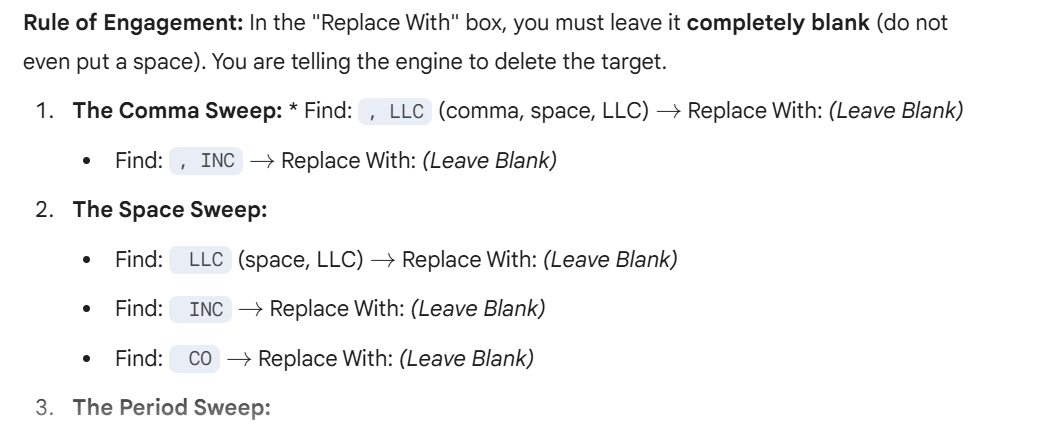

# AGGREGATE DATA

In [ ]:
path_agg = '/content/drive/MyDrive/A1_IOWA/sales_history_V1.parquet'
import duckdb

In [ ]:

q = f"""
SELECT
   *
FROM '{path_agg}'
limit 5


"""
r=duckdb.query(q).df()
r

,date,store_location,sale_dollars,bottles_sold,state_bottle_retail,state_bottle_cost,volume_sold_liters,bottle_volume_ml,clean_city,clean_county,clean_store_name,clean_address,clean_item_description,extra_clean_vendor_name
0,2023-07-12,POINT(-93.797594027 41.558407006),2907.00,102,28.50,19.00,178.5,1750,WEST DES MOINES,POLK,WAL-MART 3762 / WDM,6365 STAGECOACH DR,TITOS HANDMADE VODKA,FIFTH GENERATION INC
1,2024-05-10,POINT(-90.538977463 41.809946437),4050.00,180,22.50,15.00,180.0,1000,DEWITT,CLINTON,ANOTHER ROUND / DEWITT,622 S 6TH AVE,JOSE CUERVO ESPECIAL REPOSADO,PROXIMO
2,2023-01-23,POINT(-90.63733 41.53816),259.20,192,1.50,1.00,19.2,100,DAVENPORT,SCOTT,SUB EXPRESS & GAS,4307 W LOCUST ST,FIREBALL CINNAMON WHISKEY,SAZERAC COMPANY INC
3,2022-12-02,POINT(-93.61897 41.6277),859.32,36,23.87,15.91,27.0,750,DES MOINES,POLK,FAREWAY STORES #900 / EUCLID,100 EUCLID AVE,JACK DANIELS OLD #7 BLACK LABEL,BROWN FORMAN CORP
4,2024-02-16,POINT(-90.538996227 41.809630534),2520.00,60,42.00,28.00,45.0,750,DEWITT,CLINTON,ANOTHER ROUND / DEWITT,622 S 6TH AVE,PATRON SILVER,BACARDI USA INC


In [ ]:
import duckdb
import pandas as pd

# 2. The SQL Engine (The Arc Reactor)
# Note: I am assuming standard Iowa dataset column names for Date and Sales.
# If your column names are different (e.g., 'Date' instead of 'date', 'Sale (Dollars)' instead of 'sale_dollars'),
# you MUST change them in the query below or it will throw an error.

q = f"""
create or replace view data_agg as
    SELECT
        extra_clean_vendor_name,
        -- Truncate the daily date to the first of the month to kill the noise
        DATE_TRUNC('month', CAST(date AS DATE)) AS sales_month,

        -- Aggregate the metrics that actually matter
        SUM("sale_dollars") AS total_revenue,
        SUM("volume_sold_liters") AS total_volume,
        COUNT(*) AS total_transactions

    FROM read_parquet('{path_agg}')

    -- Filter out garbage records where we don't know the vendor
    WHERE extra_clean_vendor_name IS NOT NULL
      AND date IS NOT NULL

    GROUP BY
        extra_clean_vendor_name,
        sales_month

    ORDER BY
        sales_month ASC,
        total_revenue DESC
"""
duckdb.query(q)
print('completed')

completed


## save

In [ ]:
path_update = '/content/drive/MyDrive/A1_IOWA/sales_his_aggregate.parquet'

duckdb.sql(f"""
COPY data_agg
TO '{path_update}'
(FORMAT PARQUET);
""")


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))